In [1]:
pip install scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

import joblib

In [3]:
orders = pd.read_csv("../data/cleaned/orders_clean.csv")

In [4]:
orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,Sales,Profit,Month,Year,Quarter,ProfitMargin,AverageOrderValue
0,O001,2024-03-09,C002,P040,1,696,2739,1223,3,2024,1,44.651333,2739.000000
1,O002,2024-03-26,C015,P009,5,1482,15193,8403,3,2024,1,55.308366,3038.600000
2,O003,2024-05-02,C029,P025,3,1132,51965,9368,5,2024,2,18.027519,17321.666667
3,O004,2024-02-24,C032,P020,2,1154,4252,1438,2,2024,1,33.819379,2126.000000
4,O005,2024-05-12,C029,P027,1,1316,53615,11859,5,2024,2,22.118810,53615.000000


In [5]:
X = orders[[
    "Quantity",
    "Discount",
    "Profit",
    "Month"
]]
y = orders["Sales"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [7]:
model = LinearRegression()

In [8]:
model.fit(

    X_train,

    y_train

)

LinearRegression()

In [9]:
predictions = model.predict(X_test)

In [10]:
results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": predictions

})

results.head()

,Actual,Predicted
13,7465,15801.595847
39,273719,266937.744534
30,69661,47005.489017
45,16251,31734.922629
17,49282,49334.505750


In [11]:
mae = mean_absolute_error(

    y_test,

    predictions

)

print(mae)

9464.63920734628


In [12]:
mse = mean_squared_error(

    y_test,

    predictions

)

print(mse)

131998394.02978306


In [13]:
r2 = r2_score(

    y_test,

    predictions

)

print(r2)

0.9774427152101205


In [14]:
import joblib

model = joblib.load("../models/sales_prediction.pkl")

print(model)

LinearRegression()


In [15]:
import joblib

joblib.dump(
    model,
    "../models/sales_prediction.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [16]:
import os

print(os.path.exists("../models/sales_prediction.pkl"))

True


In [17]:
from pathlib import Path
import joblib

BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / "models" / "sales_prediction.pkl"

loaded_model = joblib.load(MODEL_PATH)

print(loaded_model)

LinearRegression()


In [18]:
pd.read_csv("../data/cleaned/orders_clean.csv")

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,Sales,Profit,Month,Year,Quarter,ProfitMargin,AverageOrderValue
0,O001,2024-03-09,C002,P040,1,696,2739,1223,3,2024,1,44.651333,2739.000000
1,O002,2024-03-26,C015,P009,5,1482,15193,8403,3,2024,1,55.308366,3038.600000
2,O003,2024-05-02,C029,P025,3,1132,51965,9368,5,2024,2,18.027519,17321.666667
3,O004,2024-02-24,C032,P020,2,1154,4252,1438,2,2024,1,33.819379,2126.000000
4,O005,2024-05-12,C029,P027,1,1316,53615,11859,5,2024,2,22.118810,53615.000000
5,O006,2024-04-04,C046,P005,4,830,6118,2414,4,2024,2,39.457339,1529.500000
6,O007,2024-03-03,C025,P042,3,735,8634,3237,3,2024,1,37.491313,2878.000000
7,O008,2024-06-12,C036,P002,3,514,74558,20006,6,2024,2,26.832801,24852.666667
8,O009,2024-05-30,C039,P034,4,469,11795,4939,5,2024,2,41.873675,2948.750000
9,O010,2024-02-25,C014,P034,1,600,2466,752,2,2024,1,30.494728,2466.000000


In [19]:
joblib.load("../models/sales_prediction.pkl")
joblib.dump(model, "../models/sales_prediction.pkl")

['../models/sales_prediction.pkl']

In [20]:
import matplotlib.pyplot as plt

In [21]:
import pandas as pd

orders = pd.read_csv("../data/cleaned/orders_clean.csv")
customers = pd.read_csv("../data/cleaned/customers_clean.csv")
products = pd.read_csv("../data/cleaned/products_clean.csv")

In [22]:
merged = orders.merge(products, on="ProductID")
merged = merged.merge(customers, on="CustomerID")

print(merged.head())

  OrderID   OrderDate CustomerID ProductID  Quantity  Discount  Sales  Profit  \
0    O001  2024-03-09       C002      P040         1       696   2739    1223   
1    O002  2024-03-26       C015      P009         5      1482  15193    8403   
2    O003  2024-05-02       C029      P025         3      1132  51965    9368   
3    O004  2024-02-24       C032      P020         2      1154   4252    1438   
4    O005  2024-05-12       C029      P027         1      1316  53615   11859   

   Month  Year  ...    ProductName     Category  Price   Cost   CustomerName  \
0      3  2024  ...  Headphones 40  Accessories   3435   1516      Amit Nair   
1      3  2024  ...   Headphones 9  Accessories   3335   1358   Rohan Jagtap   
2      5  2024  ...      Tablet 25  Electronics  17699  14199   Nikhil Gupta   
3      2  2024  ...  Headphones 20  Accessories   2703   1407  Sakshi Jagtap   
4      5  2024  ...      Laptop 27  Electronics  54931  41756   Nikhil Gupta   

   Gender  Age       City       

In [23]:
import plotly.express as px

fig = px.bar(
    merged,
    x="ProductName",
    y="Sales",
    color="Category",
    title="Monthly Sales by Product"
)

fig.show()

In [24]:
import os

os.makedirs("../reports", exist_ok=True)

fig.write_html("../reports/monthly_sales.html")

In [25]:
print(merged.head())

  OrderID   OrderDate CustomerID ProductID  Quantity  Discount  Sales  Profit  \
0    O001  2024-03-09       C002      P040         1       696   2739    1223   
1    O002  2024-03-26       C015      P009         5      1482  15193    8403   
2    O003  2024-05-02       C029      P025         3      1132  51965    9368   
3    O004  2024-02-24       C032      P020         2      1154   4252    1438   
4    O005  2024-05-12       C029      P027         1      1316  53615   11859   

   Month  Year  ...    ProductName     Category  Price   Cost   CustomerName  \
0      3  2024  ...  Headphones 40  Accessories   3435   1516      Amit Nair   
1      3  2024  ...   Headphones 9  Accessories   3335   1358   Rohan Jagtap   
2      5  2024  ...      Tablet 25  Electronics  17699  14199   Nikhil Gupta   
3      2  2024  ...  Headphones 20  Accessories   2703   1407  Sakshi Jagtap   
4      5  2024  ...      Laptop 27  Electronics  54931  41756   Nikhil Gupta   

   Gender  Age       City       

In [26]:
import plotly.io as pio

print(pio.renderers.default)

plotly_mimetype


In [31]:
import plotly.io as pio

print("Current renderer:", pio.renderers.default)

Current renderer: browser


In [32]:
import plotly.io as pio

pio.renderers.default = "notebook_connected"

In [33]:
fig.show()

In [34]:
import os

print(os.path.exists("../reports/monthly_sales.html"))

True


In [35]:
import webbrowser
import os

path = os.path.abspath("../reports/monthly_sales.html")
webbrowser.open("file://" + path)

True

In [37]:
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)
fig.show()

In [38]:
import plotly
import plotly.io as pio

print("Plotly:", plotly.__version__)
print("Renderer:", pio.renderers.default)

Plotly: 6.8.0
Renderer: plotly_mimetype+notebook_connected


In [39]:
new_data = [[

    2,

    500,

    8000,

    7

]]

In [40]:
prediction = loaded_model.predict(

    new_data

)

print(prediction)

[30517.18525719]


C:\Users\sharau jagtap\onedrive\desktop\AI_Enterprise_Intelligence_Platform\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


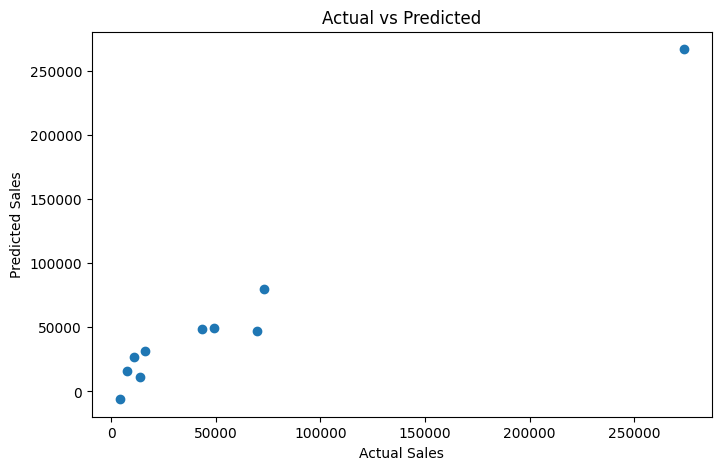

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(

    y_test,

    predictions

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()